# Results analysis

## Configuration

Everything below reads from `results/`. No GPU, no model loading.

In [1]:
# ---- what to analyse ------------------------------------------------------ #
MODEL   = "Qwen3.5-2B"        # "Qwen3.5-2B" | "Qwen3.5-0.8B" | "LFM2.5-350M"
SUBSET  = "all"               # "all" | "has_description" | "no_description"
RANKING = "ranked_ids"        # "ranked_ids" (pool of 8) | "open_ranked" (all 5,014)
METRICS = ["hit@1", "hit@3", "hit@5", "mrr", "relaxed_hit@1", "relaxed_hit@3", "relaxed_hit@5",
           "relaxed_mrr", "gen_exact"]
# --------------------------------------------------------------------------- #

import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from src.data import load_corpus, NO_DESCRIPTION
from src.metrics import load_predictions, compute, breakdown

RESULTS, FIGURES = Path("results"), Path("figures")
FIGURES.mkdir(exist_ok=True)
pd.set_option("display.width", 200, "display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
BLUE, ORANGE, GREEN, GREY = "#4C6EF5", "#F76707", "#37B24D", "#868E96"

corpus = load_corpus()
MODELS = ["LFM2.5-350M", "Qwen3.5-0.8B", "Qwen3.5-2B"]

In [2]:
# Pretty names for the runs, in the order they should appear
LABELS = {
    "baseline_random":        "random pick",
    "baseline_frequency":     "frequency prior",
    "baseline_ngram":         "n-gram + back-off",
    "baseline_lexical":       "lexical overlap (reads the sentence)",
    "baseline_lexical_order": "lexical + order (reads the sentence)",
    "zeroshot_id":            "zero-shot (no fine-tuning)",
    "id":                     "FT  id",
    "text":                   "FT  text",
    "picto_text":             "FT  picto",
    "picto_text_constrained": "FT  picto + constraints",
    "picto_image":            "FT  picto (image init)",
    "picto_textimage":        "FT  picto (text+image init)",
}

def parse(name):
    """'picto_text_Qwen3.5-2B_fullsent_constrained' -> ('picto_text_constrained', 'Qwen3.5-2B', True)"""
    if name.startswith("baseline_"):
        return name, None, None
    full = "_fullsent" in name
    rest = name.replace("_fullsent", "")
    for tag in MODELS:
        if f"_{tag}" in rest:
            return rest.replace(f"_{tag}", "", 1), tag, full
    return rest, None, full

def load(name):
    f = RESULTS / name / "predictions.jsonl"
    return load_predictions(f) if f.exists() else None

def subset(records, which=SUBSET):
    if which == "has_description":
        return [r for r in records if r.get("has_description")]
    if which == "no_description":
        return [r for r in records if r.get("has_description") is False]
    return records

def runs_for(model=MODEL, full_sentence=False, baselines=True):
    """Map pretty label -> records for one model and one setting"""
    out = {}
    for d in sorted(RESULTS.iterdir()):
        if not (d / "predictions.jsonl").exists() or d.name.startswith(("randneg_", "_")):
            continue
        key, tag, full = parse(d.name)
        if tag is None:
            if baselines and (full_sentence or "lexical" not in key):
                out[LABELS.get(key, key)] = load(d.name)
        elif tag == model and full == full_sentence and "seed" not in key:
            out[LABELS.get(key, key)] = load(d.name)
    return out

def results_table(runs, metrics=METRICS, ranking=RANKING, which=SUBSET):
    """Metrics for each run as a DataFrame, with a +/- column per metric"""
    rows = {}
    for label, recs in runs.items():
        m = compute(subset(recs, which), corpus.equivalence, rank_key=ranking)
        if not m.get("n"):
            continue
        row = {"n": m["n"]}
        for k in metrics:
            if k in m:
                row[k] = round(m[k], 3)
                ci = m.get(f"{k}_ci")
                row[f"{k} ±"] = round((ci[1] - ci[0]) / 2, 3) if ci else np.nan
        rows[label] = row
    df = pd.DataFrame(rows).T
    order = [l for l in LABELS.values() if l in df.index]
    return df.loc[order + [l for l in df.index if l not in order]]

RUNS = runs_for()
print(f"{len(RUNS)} runs loaded for MODEL={MODEL!r}, default setting")

8 runs loaded for MODEL='Qwen3.5-2B', default setting


## 1. Data

54,797 sentences, each an ordered list of pictogram ids, plus metadata and a PNG
for 12,464 pictograms. **13.6 % of the pictograms the model must predict have no
text metadata at all**, which motivates the vision experiment.

In [3]:
cat = corpus.catalogue
sent = pd.concat(corpus.splits.values())
empty = [p for p in corpus.vocab_ids
         if corpus.description.get(p, NO_DESCRIPTION) == NO_DESCRIPTION]

pd.DataFrame({
    "value": [
        f"{len(cat):,}",
        f"{(~cat['has_metadata']).sum():,}  ({(~cat['has_metadata']).mean():.1%})",
        f"{len(sent):,}",
        f"{sent['n_pictos'].mean():.2f}",
        f"{sum(len(v) for v in corpus.steps.values()):,}",
        f"{len(corpus.vocab_ids):,}",
        f"{len(empty):,}  ({len(empty)/len(corpus.vocab_ids):.1%})",
    ]},
    index=["pictograms in the catalogue", "  ... with no metadata at all",
           "sentences used", "mean pictograms per sentence", "decision steps",
           "label space", "  ... with no description"])

,value
pictograms in the catalogue,"12,464"
... with no metadata at all,"1,807 (14.5%)"
sentences used,"15,500"
mean pictograms per sentence,4.20
decision steps,"65,026"
label space,"5,014"
... with no description,681 (13.6%)


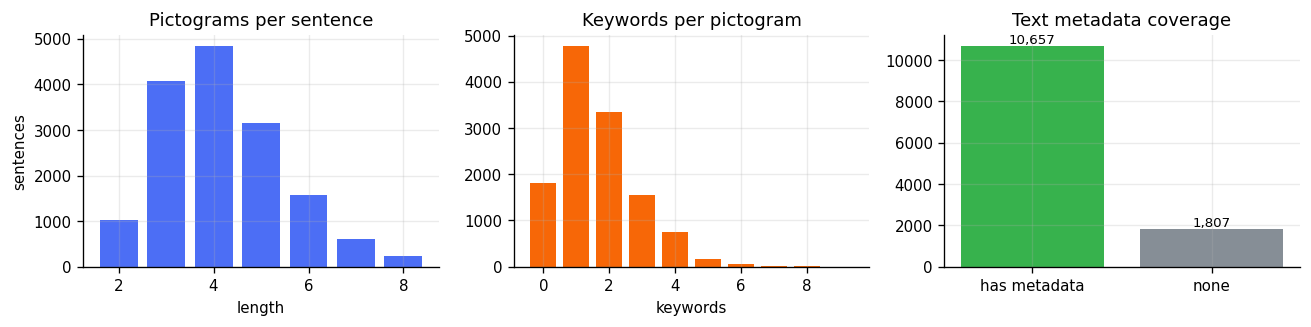

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(11, 2.8))
c = sent["n_pictos"].value_counts().sort_index()
ax[0].bar(c.index, c.values, color=BLUE)
ax[0].set(title="Pictograms per sentence", xlabel="length", ylabel="sentences")

ax[1].hist(cat["keywords"].apply(len), bins=range(0, 11), color=ORANGE, align="left", rwidth=.8)
ax[1].set(title="Keywords per pictogram", xlabel="keywords")

has = cat["has_metadata"].value_counts()
ax[2].bar(["has metadata", "none"], [has.get(True, 0), has.get(False, 0)], color=[GREEN, GREY])
ax[2].set(title="Text metadata coverage")
for i, v in enumerate([has.get(True, 0), has.get(False, 0)]):
    ax[2].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

plt.tight_layout(); plt.savefig(FIGURES / "01_data.png", bbox_inches="tight"); plt.show()

## 2. Candidate pools

Each step offers 8 candidates: the pictograms the sentence still needs (the gold
and the later ones) plus distractors retrieved with TF-IDF against the sentence.
With random distractors a frequency prior scores 0.42 without reading
anything; the retrieval pool removes that shortcut.

In [5]:
comp = {}
for regime, path in [("retrieval negatives", "baselines.json"),
                     ("random negatives", "baselines_random.json")]:
    for name, m in json.loads((RESULTS / path).read_text()).items():
        comp.setdefault(name, {})[regime] = round(m["hit@1"], 3)
pd.DataFrame(comp).T.rename_axis("baseline (hit@1)")

,retrieval negatives,random negatives
baseline (hit@1),,
random,0.121,0.124
frequency,0.379,0.420
ngram,0.387,0.442
lexical,0.074,0.289
lexical_order,0.077,0.328


## 3. The three output representations

`id` and `text` get the same prompt and differ only in the target. `picto` has
no candidate list and writes the chosen pictograms as tokens.

In [6]:
from src.prompts import build_prompt, build_target, system_prompt, MODES
step = next(s for s in corpus.steps["test"] if s["step_id"] == "1934:1")
for mode in MODES:
    print("=" * 78, f"\nMODE: {mode}\n" + "-" * 78)
    print("[system]", system_prompt(mode, include_sentence=False))
    print(build_prompt(step, corpus, mode))
    print(f"   TARGET: {build_target(step, corpus, mode)!r}\n")

MODE: id
------------------------------------------------------------------------------
[system] You help build sentences with ARASAAC pictograms. Given the pictograms already chosen and a list of candidates, reply with the id of the next pictogram. Reply with the id only.
Selected: banana (fruit, core vocabulary-feeding)
Candidates:
13645 apple (fruit)
2619 carrot (vegetable)
2839 pepper, red pepper, bell pepper (vegetable)
13644 apple (fruit)
2838 pepper, green pepper, bell pepper (vegetable)
37614 red green glasses, red green anaglyph glasses (medical equipment, ophthalmology)
10218 banana (fruit)
9054 banana (fruit)
Next:
   TARGET: '2839'

MODE: text
------------------------------------------------------------------------------
[system] You help build sentences with ARASAAC pictograms. Given the pictograms already chosen and a list of candidates, reply with the description of the next pictogram. Reply with the description only.
Selected: banana (fruit, core vocabulary-feeding)
Can

## 4. Results

Pool of 8, 8,467 test decisions, 95 % Wilson intervals. `strict` requires the
exact gold pictogram; `relaxed` accepts any pictogram sharing a keyword with it.
The lexical baselines read the sentence, so they only appear in section 8.

In [7]:
TABLE = results_table(RUNS)
TABLE

,n,hit@1,hit@1 ±,hit@3,hit@3 ±,hit@5,hit@5 ±,mrr,mrr ±,relaxed_hit@1,relaxed_hit@1 ±,relaxed_hit@3,relaxed_hit@3 ±,relaxed_hit@5,relaxed_hit@5 ±,relaxed_mrr,relaxed_mrr ±,gen_exact,gen_exact ±
random pick,8467.0,0.121,0.007,0.365,0.010,0.619,0.010,0.335,0.006,0.144,0.007,0.405,0.010,0.655,0.010,0.360,0.006,NaN,NaN
frequency prior,8467.0,0.379,0.010,0.774,0.009,0.940,0.005,0.597,0.007,0.389,0.010,0.786,0.009,0.944,0.005,0.606,0.007,NaN,NaN
n-gram + back-off,8467.0,0.387,0.010,0.782,0.009,0.941,0.005,0.603,0.007,0.398,0.010,0.793,0.009,0.944,0.005,0.613,0.007,NaN,NaN
FT id,8467.0,0.508,0.011,0.867,0.007,0.969,0.004,0.696,0.007,0.518,0.011,0.880,0.007,0.975,0.003,0.705,0.007,0.496,0.011
FT text,8467.0,0.472,0.011,0.815,0.008,0.933,0.005,0.660,0.007,0.487,0.011,0.827,0.008,0.939,0.005,0.672,0.007,0.369,0.010
FT picto,8467.0,0.392,0.010,0.785,0.009,0.946,0.005,0.607,0.007,0.404,0.010,0.794,0.009,0.948,0.005,0.616,0.007,0.041,0.004
FT picto + constraints,8467.0,0.398,0.010,0.789,0.009,0.947,0.005,0.611,0.007,0.410,0.010,0.798,0.009,0.949,0.005,0.621,0.007,0.041,0.004
FT picto (image init),8467.0,0.401,0.010,0.799,0.009,0.955,0.004,0.617,0.007,0.413,0.010,0.808,0.008,0.957,0.004,0.626,0.007,0.040,0.004


### 4.1 Three models

Strict Hit@1 for every model and output mode, same data and hyperparameters.

In [8]:
grid = {}
for mode, key in [("id", "id"), ("text", "text"), ("picto", "picto_text")]:
    for tag in MODELS:
        recs = load(f"{key}_{tag}")
        if recs:
            grid.setdefault(mode, {})[tag] = compute(subset(recs), corpus.equivalence)["hit@1"]
GRID = pd.DataFrame(grid).T.reindex(columns=MODELS).round(3)
GRID

,LFM2.5-350M,Qwen3.5-0.8B,Qwen3.5-2B
id,0.432,0.500,0.508
text,0.444,0.463,0.472
picto,0.391,0.391,0.392


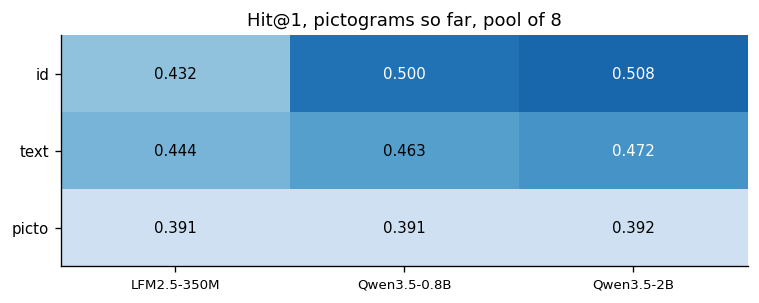

In [9]:
# Heatmap: one cell per (mode, model)
fig, ax = plt.subplots(figsize=(6.4, 2.6))
im = ax.imshow(GRID.values.astype(float), cmap="Blues", vmin=0.35, vmax=0.55, aspect="auto")
ax.set_xticks(range(GRID.shape[1]), GRID.columns, fontsize=8)
ax.set_yticks(range(GRID.shape[0]), GRID.index)
ax.grid(False)
for i in range(GRID.shape[0]):
    for j in range(GRID.shape[1]):
        v = GRID.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                    color="white" if v > 0.47 else "black")
ax.set_title("Hit@1, pictograms so far, pool of 8")
plt.tight_layout(); plt.savefig(FIGURES / "02_models.png", bbox_inches="tight"); plt.show()

### 4.2 Along the sentence

Hit@1 by position t. At t = 0 nothing has been chosen yet.

In [10]:
rows = {}
for label, recs in RUNS.items():
    b = breakdown(subset(recs), lambda r: min(int(r["t"]), 5), corpus.equivalence)
    rows[label] = {("t=5+" if k == 5 else f"t={k}"): round(v["hit@1"], 3) for k, v in sorted(b.items())}
BY_STEP = pd.DataFrame(rows).T
BY_STEP

,t=0,t=1,t=2,t=3,t=4,t=5+
frequency prior,0.241,0.323,0.412,0.472,0.514,0.581
n-gram + back-off,0.241,0.347,0.420,0.473,0.521,0.571
random pick,0.131,0.135,0.114,0.108,0.102,0.112
FT id,0.391,0.415,0.533,0.610,0.678,0.732
FT picto (image init),0.322,0.348,0.415,0.472,0.499,0.550
FT picto,0.315,0.336,0.419,0.448,0.492,0.520
FT picto + constraints,0.315,0.343,0.428,0.458,0.501,0.524
FT text,0.353,0.371,0.493,0.588,0.637,0.721


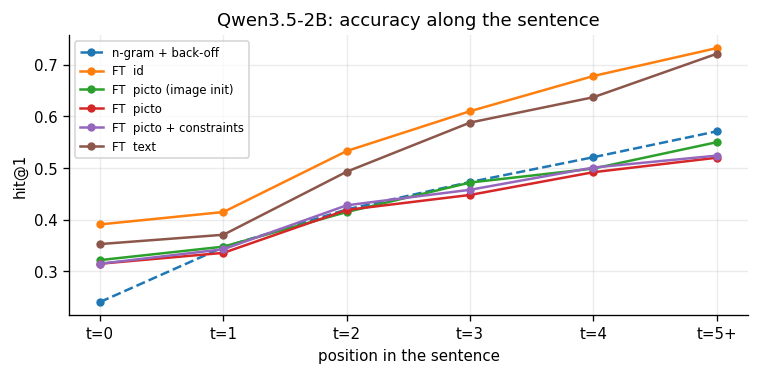

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
show = [l for l in BY_STEP.index if l.startswith("FT") or "n-gram" in l]
for label in show:
    row = BY_STEP.loc[label]
    ax.plot(range(len(row)), row.values, marker="o", ms=4, label=label.strip(),
            ls="--" if "n-gram" in label else "-")
ax.set(xlabel="position in the sentence", ylabel="hit@1", title=f"{MODEL}: accuracy along the sentence")
ax.set_xticks(range(BY_STEP.shape[1]), BY_STEP.columns)
ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIGURES / "03_by_step.png", bbox_inches="tight"); plt.show()

### 4.3 The metadata split

All steps, and the easier subset where the gold pictogram has a description.

In [12]:
rows = {}
for label, recs in RUNS.items():
    for name, which in [("all", "all"), ("has description", "has_description"),
                        ("NO description", "no_description")]:
        m = compute(subset(recs, which), corpus.equivalence)
        if m.get("n"):
            rows.setdefault(label, {})[name] = round(m["hit@1"], 3)
            rows[label][f"{name} (n)"] = m["n"]
BY_META = pd.DataFrame(rows).T
BY_META[["all", "has description", "NO description"]]

,all,has description,NO description
frequency prior,0.379,0.388,0.309
n-gram + back-off,0.387,0.395,0.324
random pick,0.121,0.121,0.118
FT id,0.508,0.495,0.609
FT picto (image init),0.401,0.409,0.342
FT picto,0.392,0.407,0.272
FT picto + constraints,0.398,0.412,0.291
FT text,0.472,0.493,0.307


## 5. Vision: picto tokens initialised from the image

For pictograms without a description the text initialisation falls back to
random. The image initialisation uses the model's own vision encoder instead.

In [13]:
rows = {}
for tag in MODELS:
    for init in ("text", "image"):
        recs = load(f"picto_{init}_{tag}")
        if not recs:
            continue
        for which in ("has_description", "no_description"):
            m = compute(subset(recs, which), corpus.equivalence)
            rows.setdefault(f"{tag}, {init} init", {})[which] = round(m["hit@1"], 3)
VISION = pd.DataFrame(rows).T
VISION

,has_description,no_description
"LFM2.5-350M, text init",0.408,0.266
"Qwen3.5-0.8B, text init",0.406,0.272
"Qwen3.5-0.8B, image init",0.412,0.342
"Qwen3.5-2B, text init",0.407,0.272
"Qwen3.5-2B, image init",0.409,0.342


## 6. Constrained decoding

A prefix tree records which pictograms followed which; candidates outside it are
suppressed. The study re-ranks the saved scores, so it costs no GPU time. The
test-coverage sweep adds a growing share of the test sentences to the tree: it
is leaky by construction and shows how the gain grows with coverage.

In [14]:
study = json.loads((RESULTS / "constraint_study.json").read_text()).get("runs", {})
CONSTRAINTS = {run: pd.DataFrame(rows) for run, rows in study.items()}
for run, df in CONSTRAINTS.items():
    print(run)
    display(df[[c for c in ["setting", "hit@1", "hit@1_sd", "hit@1_covered",
                            "hit@1_uncovered", "gold_removed"] if c in df]].round(3))

picto_text_Qwen3.5-2B


,setting,hit@1,hit@1_sd,hit@1_covered,hit@1_uncovered,gold_removed
0,no constraint,0.392,NaN,NaN,NaN,0.000
1,10% of non-test data,0.400,NaN,NaN,NaN,0.174
2,25% of non-test data,0.401,NaN,NaN,NaN,0.187
3,50% of non-test data,0.403,NaN,NaN,NaN,0.194
4,100% of non-test data,0.407,NaN,NaN,NaN,0.195
5,non-test + 0% of test,0.407,0.000,NaN,0.407,0.195
6,non-test + 10% of test,0.436,0.001,0.699,0.407,0.175
7,non-test + 25% of test,0.480,0.003,0.701,0.407,0.146
8,non-test + 50% of test,0.555,0.002,0.705,0.406,0.096
9,non-test + 75% of test,0.632,0.002,0.707,0.406,0.047


picto_text_Qwen3.5-2B_fullsent


,setting,hit@1,hit@1_sd,hit@1_covered,hit@1_uncovered,gold_removed
0,no constraint,0.679,NaN,NaN,NaN,0.000
1,10% of non-test data,0.616,NaN,NaN,NaN,0.174
2,25% of non-test data,0.606,NaN,NaN,NaN,0.187
3,50% of non-test data,0.603,NaN,NaN,NaN,0.194
4,100% of non-test data,0.601,NaN,NaN,NaN,0.195
5,non-test + 0% of test,0.601,0.000,NaN,0.601,0.195
6,non-test + 10% of test,0.627,0.001,0.854,0.602,0.175
7,non-test + 25% of test,0.664,0.001,0.857,0.601,0.146
8,non-test + 50% of test,0.731,0.002,0.862,0.599,0.096
9,non-test + 75% of test,0.796,0.001,0.862,0.600,0.047


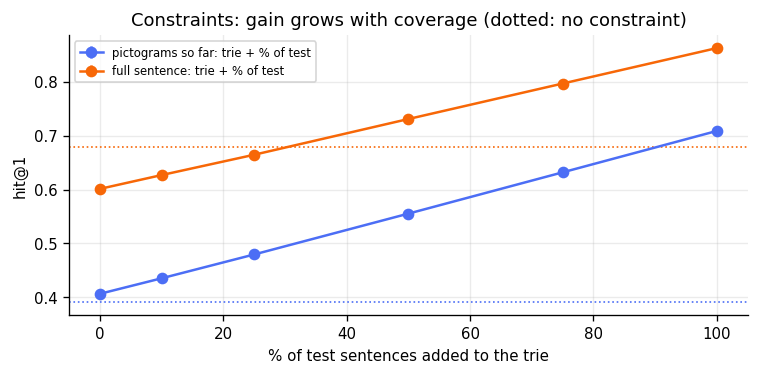

In [15]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for (run, df), color in zip(CONSTRAINTS.items(), [BLUE, ORANGE]):
    test = df[df["sweep"] == "test"]
    base = df.loc[df["sweep"] == "none", "hit@1"].iloc[0]
    label = "full sentence" if "fullsent" in run else "pictograms so far"
    ax.errorbar(test["fraction"] * 100, test["hit@1"], yerr=test["hit@1_sd"],
                marker="o", color=color, label=f"{label}: trie + % of test")
    ax.axhline(base, color=color, ls=":", lw=1)
ax.set(xlabel="% of test sentences added to the trie", ylabel="hit@1",
       title="Constraints: gain grows with coverage (dotted: no constraint)")
ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIGURES / "05_constraints.png", bbox_inches="tight"); plt.show()

## 7. Training-seed variance

The confidence intervals only cover which test sentences were drawn. Retraining
with another seed measures the other source of noise.

In [16]:
rows = {}
for label, name in [("seed 42", "picto_text_Qwen3.5-0.8B"),
                    ("seed 43", "picto_text_Qwen3.5-0.8B_seed43")]:
    recs = load(name)
    if recs:
        rows[label] = {which: round(compute(subset(recs, which), corpus.equivalence)["hit@1"], 3)
                       for which in ["all", "has_description", "no_description"]}
SEEDS = pd.DataFrame(rows).T
if len(SEEDS) == 2:
    SEEDS.loc["difference"] = (SEEDS.iloc[1] - SEEDS.iloc[0]).round(3)
SEEDS

,all,has_description,no_description
seed 42,0.391,0.406,0.272
seed 43,0.391,0.407,0.263
difference,0.000,0.001,-0.009


## 8. Upper bound: the whole sentence in the prompt

The same runs with the target sentence added to the prompt. The model then knows
what the user wants to say, including the future words: an optimistic setting,
kept for reference. These predictions are not shipped with the repository;
`FULL_SENTENCE=1 ./run_all.sh` (with `MODEL=...` for the other models)
regenerates them, and the cells below skip what is missing.

In [17]:
rows = {}
for mode, key in [("id", "id"), ("text", "text"), ("picto", "picto_text")]:
    for tag in MODELS:
        so_far, full = load(f"{key}_{tag}"), load(f"{key}_{tag}_fullsent")
        if so_far and full:
            rows[f"{mode}, {tag}"] = {
                "pictograms so far": round(compute(so_far, corpus.equivalence)["hit@1"], 3),
                "full sentence": round(compute(full, corpus.equivalence)["hit@1"], 3)}
UPPER = pd.DataFrame(rows).T
UPPER if len(UPPER) else print("full-sentence runs not present")

,pictograms so far,full sentence
"id, LFM2.5-350M",0.432,0.586
"id, Qwen3.5-0.8B",0.500,0.747
"id, Qwen3.5-2B",0.508,0.784
"text, LFM2.5-350M",0.444,0.611
"text, Qwen3.5-0.8B",0.463,0.738
"text, Qwen3.5-2B",0.472,0.755
"picto, LFM2.5-350M",0.391,0.635
"picto, Qwen3.5-0.8B",0.391,0.667
"picto, Qwen3.5-2B",0.392,0.679


In [18]:
FULL = {k: v for k, v in runs_for(full_sentence=True).items() if not k.startswith(("random", "frequency", "n-gram"))}
results_table(FULL) if any(k.startswith(("FT", "zero")) for k in FULL) else print("full-sentence runs not present")

,n,hit@1,hit@1 ±,hit@3,hit@3 ±,hit@5,hit@5 ±,mrr,mrr ±,relaxed_hit@1,relaxed_hit@1 ±,relaxed_hit@3,relaxed_hit@3 ±,relaxed_hit@5,relaxed_hit@5 ±,relaxed_mrr,relaxed_mrr ±,gen_exact,gen_exact ±
lexical overlap (reads the sentence),8467.0,0.074,0.006,0.184,0.008,0.304,0.010,0.242,0.005,0.106,0.007,0.220,0.009,0.323,0.010,0.270,0.006,NaN,NaN
lexical + order (reads the sentence),8467.0,0.077,0.006,0.174,0.008,0.288,0.010,0.240,0.005,0.106,0.007,0.194,0.008,0.302,0.010,0.262,0.006,NaN,NaN
zero-shot (no fine-tuning),8467.0,0.143,0.007,0.417,0.010,0.677,0.010,0.362,0.006,0.160,0.008,0.451,0.011,0.702,0.010,0.382,0.006,0.132,0.007
FT id,8467.0,0.784,0.009,0.966,0.004,0.993,0.002,0.874,0.005,0.800,0.009,0.971,0.004,0.995,0.001,0.884,0.005,0.780,0.009
FT text,8467.0,0.755,0.009,0.939,0.005,0.981,0.003,0.851,0.006,0.778,0.009,0.944,0.005,0.984,0.003,0.864,0.006,0.605,0.010
FT picto,8467.0,0.679,0.010,0.919,0.006,0.977,0.003,0.804,0.006,0.695,0.010,0.922,0.006,0.979,0.003,0.813,0.006,0.384,0.010
FT picto + constraints,8467.0,0.604,0.010,0.911,0.006,0.977,0.003,0.760,0.007,0.619,0.010,0.914,0.006,0.978,0.003,0.770,0.006,0.384,0.010
FT picto (image init),8467.0,0.699,0.010,0.930,0.005,0.982,0.003,0.819,0.006,0.715,0.010,0.933,0.005,0.983,0.003,0.828,0.006,0.379,0.010
FT picto (text+image init),8467.0,0.697,0.010,0.928,0.005,0.981,0.003,0.817,0.006,0.713,0.010,0.931,0.005,0.982,0.003,0.826,0.006,0.395,0.010


## 9. Error analysis

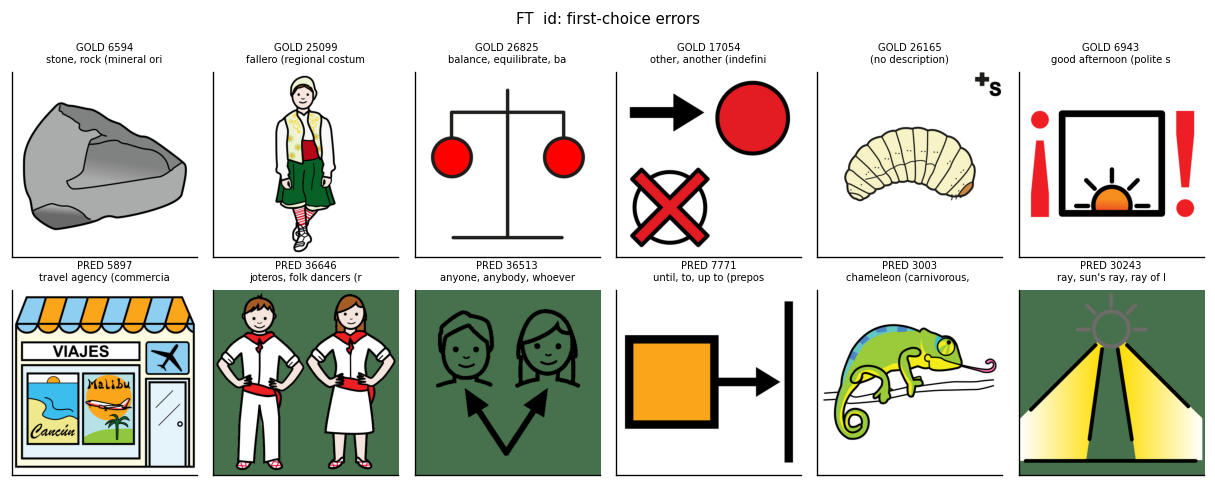

In [19]:
from io import BytesIO
from PIL import Image
from datasets import Image as HFImage
from src.data import _load_hf, PICTOGRAMS_REPO, PICTOGRAMS_REVISION

_IMG = {}
def picto_image(pid):
    if not _IMG:
        ds = _load_hf(PICTOGRAMS_REPO, PICTOGRAMS_REVISION).cast_column("image", HFImage(decode=False))
        for row in ds:
            _IMG[int(row["pictogram_id"])] = row["image"]["bytes"]
    raw = _IMG.get(int(pid))
    return Image.open(BytesIO(raw)).convert("RGB") if raw else None

def show_errors(label, n=6, seed=0):
    recs = [r for r in RUNS[label] if r["ranked_ids"][0] != r["gold_id"]]
    picks = [recs[i] for i in np.random.default_rng(seed).choice(len(recs), n, replace=False)]
    fig, axes = plt.subplots(2, n, figsize=(1.7 * n, 4.2))
    for j, r in enumerate(picks):
        for row, pid in enumerate([r["gold_id"], r["ranked_ids"][0]]):
            a = axes[row, j]
            img = picto_image(pid)
            if img is not None: a.imshow(img)
            a.set_xticks([]); a.set_yticks([])
            a.set_title(("GOLD " if row == 0 else "PRED ") +
                        f"{pid}\n{corpus.description.get(pid,'?')[:24]}", fontsize=6)
    fig.suptitle(f"{label}: first-choice errors", fontsize=9)
    plt.tight_layout(); plt.savefig(FIGURES / "04_errors.png", bbox_inches="tight"); plt.show()

ft = [l for l in RUNS if l.startswith("FT")]
if ft:
    show_errors(max(ft, key=lambda l: compute(RUNS[l], corpus.equivalence)["hit@1"]))

In [20]:
# How many "errors" are near-synonyms the strict metric refuses to credit?
pd.DataFrame({
    label: {
        "strict":  round(compute(subset(r), corpus.equivalence)["hit@1"], 3),
        "relaxed": round(compute(subset(r), corpus.equivalence)["relaxed_hit@1"], 3),
    } for label, r in RUNS.items()
}).T.assign(recovered=lambda d: (d["relaxed"] - d["strict"]).round(3))

,strict,relaxed,recovered
frequency prior,0.379,0.389,0.010
n-gram + back-off,0.387,0.398,0.011
random pick,0.121,0.144,0.023
FT id,0.508,0.518,0.010
FT picto (image init),0.401,0.413,0.012
FT picto,0.392,0.404,0.012
FT picto + constraints,0.398,0.410,0.012
FT text,0.472,0.487,0.015
